## All-in one notebook to locally run Katja's tracking algorithm (preprocessing, running, postprocessing and plotting). It may needs some minor adjustements to make sure it runs smoothly for different dataset, especially with an irregular grid

Last update: November 2024

In [33]:
import xarray as xr
from glob import glob
import os 
import numpy as np
import dask_image.ndfilters
from braceexpand import braceexpand
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
import datetime as dt
import cartopy

In [34]:
def calc_grid_distance_area(longitude, latitude):
    """ Function to calculate grid parameters
        It uses haversine function to approximate distances
        It approximates the first row and column to the sencond
        because coordinates of grid cell center are assumed
        lat, lon: input coordinates(degrees) 2D [y,x] dimensions
        dx: distance (m)
        dy: distance (m)
        area: area of grid cell (m2)
        grid_distance: average grid distance over the domain (m)
    """

    if longitude.ndim < 2:
        lon, lat = np.meshgrid(longitude, latitude)
    else:
        lon, lat = longitude, latitude
    
    dy = np.zeros(lon.shape)
    dx = np.zeros(lat.shape)

    dx[:,1:]=haversine(lon[:,1:],lat[:,1:],lon[:,:-1],lat[:,:-1])
    dy[1:,:]=haversine(lon[1:,:],lat[1:,:],lon[:-1,:],lat[:-1,:])

    dx[:,0] = dx[:,1]
    dy[0,:] = dy[1,:]
    
    dx = dx * 10**3
    dy = dy * 10**3

    area = dx*dy
    grid_distance = np.mean(np.append(dy[:, :, None], dx[:, :, None], axis=2))

    return dx,dy,area,grid_distance

In [35]:
def haversine(lon1, lat1, lon2, lat2):
    """
    Calculate the great circle distance between two points
    on the earth (specified in decimal degrees)
    """
    # convert decimal degrees to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c
    return km

In [36]:
def convert_lon_lat(ds, var_lon, var_lat):
    """Convert lon and lat coordinate on a -180:180 ; -90:90 grid, respectively.
   
    Args:
      dataset (xarray.Dataset): Input file
      str: Longitude dimension name
      str: Latitude dimension name
    
    """
    if ds[var_lon].ndim == 2: #if longitude and latitude are 2D arrays depending on x and y
        
        print('Longitude and Latitude are 2D arrays')

        if (ds[var_lon] >= 180.).any():
            ds[var_lon] = (((ds[var_lon] + 180) % 360) - 180)
            print('Longitude converted on a -180:180 grid')

        if (ds[var_lat] > 90.).any():
            print(ds[var_lat].values)
            ds[var_lat] = (((ds[var_lat] + 90) % 180) - 90)
            print('Latitude converted on a 90:-90 grid')

        ds[var_lon] = (ds[var_lon].dims, np.sort(ds[var_lon], axis=1))
        # ds[var_lat] = (ds[var_lat].dims, np.sort(ds[var_lat], axis=1)[::-1])
        
    else:
        if any(ds[var_lon] >= 180.):
            ds = ds.assign_coords({var_lon:(((ds[var_lon] + 180) % 360) - 180)})
            # ds.coords[var_lon] = (ds.coords[var_lon] + 180) % 360 - 180 #does the same job
            print('Longitude converted on a -180:180 grid')

        if any(ds[var_lat] > 90.):
            ds = ds.assign_coords({var_lat:(((ds[var_lat] + 90) % 180) - 90)})
            # ds.coords[var_lat] = (ds.coords[var_lat] + 90) % 180 - 90 #does the same job
            print('Latitude converted on a 90:-90 grid')

        ds = ds.sortby(ds[var_lon])
        # ds = ds.sortby(ds[var_lat], ascending = False)
    
        #As Prein:
        # ds = ds.sortby(ds[var_lon], ascending = True)
        # ds = ds.sortby(ds[var_lat], ascending = True)
            
    assert ds[var_lon].min() >= -180.0, 'There is at least one longitude less than -180'
    assert ds[var_lon].max() <= 180.0, 'There is at least one longitude greater than +180'
    assert ds[var_lat].min() >= -90.0, 'There is at least one latitude less than -90'
    assert ds[var_lat].max() <= 90.0, 'There is at least one latitude greater than +90'

    return ds

In [37]:
def get_mask(ds, var_lon, var_lat, west_longitude=-180, east_longitude=180, north_latitude=90, south_latitude=-90, plot=True):
    
    if ds[var_lon].ndim == 2:
        mask_lon = (ds[var_lon] >= west_longitude) & (ds[var_lon] <= east_longitude)
        mask_lat = (ds[var_lat] <= north_latitude) & (ds[var_lat] >= south_latitude)
        mask_nan = (mask_lon & mask_lat)
        masked_ds = ds.where(mask_nan)
        ds = masked_ds.dropna(dim='x', how='all').dropna(dim='y', how='all')
        
    else:
        ds = ds.sel({var_lon: slice(west_longitude, east_longitude), var_lat: slice(north_latitude, south_latitude)})
    
    if plot==True:
        if ds[var_lon].ndim == 2:
            Mask = np.copy(ds[var_lon]); Mask[:]=1
        else:
            Mask = np.ones((len(ds[var_lat]), len(ds[var_lon])))
        plotcrs = ccrs.PlateCarree()
        fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(projection=plotcrs))
        ax.set_extent([-180, 180, -90, 90], crs=plotcrs)
        ax.coastlines()
        plt.pcolormesh(
            ds[var_lon],
            ds[var_lat],
            Mask,
            transform=plotcrs,
            cmap="coolwarm",
            alpha=0.5,
        )
        plt.title('Region where storm tracking is performed')
        plt.show()
        
    return ds

In [38]:
def get_sea_level_pressure(ds):
    if hasattr(ds, 'msl'):
        slp = ds.msl
        var_psl = 'msl'
    elif hasattr(ds, 'psl'):
        slp = ds.psl
        var_psl = 'psl'
    elif hasattr(ds, 'SLP'):
        slp = ds.SLP
        var_psl = 'SLP'
    elif hasattr(ds, 'slp'):
        slp = ds.slp
        var_psl = 'slp'
    else:
        raise AttributeError(f'No variables psl, SLP, slp or msl in {input_file.split("/")[-1]}')

    try:
        slp_units = slp.attrs['units']
    except KeyError:
        raise KeyError(f'Mean sea level pressure variable in {input_file.split("/")[-1]} must have a units attribute')

    if slp_units == 'hPa':
        slp = slp / 100.
        slp.attrs['units'] = 'Pa'
    elif slp_units != 'Pa':
        raise ValueError("Mean sea level pressure units are not Pa or hPa")

    print('Slp unit: ', slp.attrs['units'])
    
    # assert slp.min() >= 90000., 'There is at least one mean sea level pressure less than 900hPa'
    # assert slp.max() < 110000., 'There is a mean sea level pressure value > 1100hPa'
    
    return slp, var_psl

In [40]:
def smooth_uniform(
            data,       # matrix to smooth [time, lat, lon]
            t_smoot,    # temporal window length [time steps]
            xy_smooth,  # spatial window [grid cells]
            ):
    '''
    Function to spatiotemporal smooth atmospheric fiels even 
    if they contain missing data
    '''
    
    if np.isnan(data).any() == False:

        smooth_data = dask_image.ndfilters.uniform_filter(data.data, size=[int(t_smoot),
                                                      int(xy_smooth),
                                                      int(xy_smooth)])

        smooth_data = xr.DataArray(smooth_data, coords=data.coords, dims=data.dims, name='slp')

    else:
        
        U = data.copy()
        V = data.copy()
        V = np.where(np.isnan(U), 0, V)
        VV = dask_image.ndfilters.uniform_filter(V.data, size=[int(t_smoot),
                                                   int(xy_smooth),
                                                   int(xy_smooth)])
        VV = xr.DataArray(VV, coords=data.coords, dims=data.dims, name='slp')
        
        W = 0*U.copy()+1
        W = np.where(np.isnan(U), 0, W) #modif vic
        WW = dask_image.ndfilters.uniform_filter(W.data, size=[int(t_smoot),
                                                   int(xy_smooth),
                                                   int(xy_smooth)])
        WW = xr.DataArray(WW, coords=data.coords, dims=data.dims, name='slp')
        
        
        smooth_data = VV/WW
        
    return smooth_data


In [41]:
def calendar_conversion(ds):
    if ds.time.encoding.get('calendar', 'No calendar attribute') != 'proleptic_gregorian':
        ds = ds.convert_calendar('proleptic_gregorian', dim='time', use_cftime=True)
        if 'calendar' not in ds.time.encoding:
            ds.time.encoding['calendar'] = 'proleptic_gregorian'
        print(f'\nCalendar converted as {ds.time.encoding.get("calendar")}\n')
    else:
        print(f'\nCalendar is already {ds.time.encoding.get("calendar")}\n')
    return ds

In [42]:
def braced_glob(path):
    l = []
    for x in braceexpand(path):
        l.extend(glob(x))
            
    return l

In [43]:
input_file = braced_glob('/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/Sea_Level_Pressure/2019/01/*.nc4')
# input_file = braced_glob('/home/vdemeyer/projects/rrg-gachon/vdemeyer/UAA/Sea_Level_Pressure/*.nc4')

ds = xr.open_mfdataset(input_file)
ds

<xarray.Dataset> Size: 6GB
Dimensions:    (latitude: 721, longitude: 1440, time: 744)
Coordinates:
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float32 6kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 6kB 2019-01-01 ... 2019-01-31T23:00:00
Data variables:
    msl        (time, latitude, longitude) float64 6GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    history:      Mon Nov 23 09:18:30 2020: ncks -7 -L 6 --cnk_map=dmn --cnk_...
    NCO:          netCDF Operators version 4.7.8 (Homepage = http://nco.sf.ne...

Longitude converted on a -180:180 grid


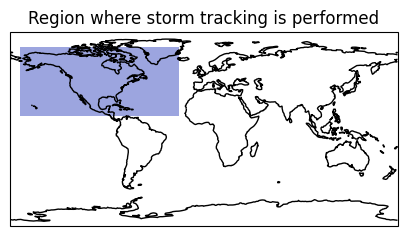

In [44]:
if hasattr(ds, 'lon'):
    var_lon, var_lat = 'lon', 'lat'
elif hasattr(ds, 'longitude'):
    var_lon, var_lat = 'longitude', 'latitude'
else:
    raise AttributeError(f'No dimension lon or longitude / lat or latitude in {input_file.split("/")[-1]}')

ds = convert_lon_lat(ds, var_lon, var_lat) #à tester avec GEM5 rlat rlon

ds = get_mask(ds, var_lon, var_lat, west_longitude=-171, east_longitude=-23, north_latitude=76, south_latitude=12, plot=True) #à tester avec GEM5 rlat rlon

In [45]:
slp, var_psl = get_sea_level_pressure(ds)
slp

Slp unit:  Pa


<xarray.DataArray 'msl' (time: 744, latitude: 257, longitude: 593)> Size: 907MB
dask.array<getitem, shape=(744, 257, 593), dtype=float64, chunksize=(1, 257, 593), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 1kB 76.0 75.75 75.5 75.25 ... 12.5 12.25 12.0
  * time       (time) datetime64[ns] 6kB 2019-01-01 ... 2019-01-31T23:00:00
  * longitude  (longitude) float32 2kB -171.0 -170.8 -170.5 ... -23.25 -23.0
Attributes:
    units:          Pa
    long_name:      Mean sea level pressure
    standard_name:  air_pressure_at_mean_sea_level

In [14]:
# for iyear in range(1979,2024):

    # ds_iyear = ds.sel(time=ds_msl.time.dt.year == iyear)

_,_,Area,Gridspacing = calc_grid_distance_area(slp[var_lon],slp[var_lat])
    
slp = smooth_uniform(slp, int(1), int(int(400/(Gridspacing/1000)))) #int(78/dT) - 3 jours / tous les 400km en moyenne ce qui correspond int(int(400/(Gridspacing/1000))) pts de grille
slp = slp.assign_attrs(units='Pa', long_name='Mean sea level pressure', standard_name='air_pressure_at_mean_sea_level')
slp = calendar_conversion(slp)
slp


Calendar converted as proleptic_gregorian



<xarray.DataArray 'msl' (time: 744, latitude: 257, longitude: 593)> Size: 907MB
dask.array<where, shape=(744, 257, 593), dtype=float64, chunksize=(1, 257, 593), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 1kB 76.0 75.75 75.5 75.25 ... 12.5 12.25 12.0
  * longitude  (longitude) float32 2kB -171.0 -170.8 -170.5 ... -23.25 -23.0
  * time       (time) object 6kB 2019-01-01 00:00:00 ... 2019-01-31 23:00:00
Attributes:
    units:          Pa
    long_name:      Mean sea level pressure
    standard_name:  air_pressure_at_mean_sea_level

In [15]:
slp.to_netcdf('/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/INPUTS/ERA5/ERA5_CORDEX_NA_psl_smoothed_400km_201901_test_pres.nc')

In [16]:
# for iyear in range(1980,2023):
#     for imonth in ['01','02','03','04','05','06','07','08','09','10','11','12']:
            
#             ds_msl_imonth = ds_msl.sel(time=f'{str(iyear)}-{imonth}')
            
#             msl_smoothed = smooth_uniform_GEM5(ds_msl_imonth.msl, int(1), int(int(400/(Gridspacing/1000)))) #int(78/dT) - 3 jours / tous les 400km en moyenne ce qui correspond int(int(400/(Gridspacing/1000))) pts de grille
#             msl_smoothed = msl_smoothed.assign_attrs(units='Pa', long_name='Mean sea level pressure', standard_name='air_pressure_at_mean_sea_level')
#             msl_smoothed.to_netcdf(f'/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/INPUTS/UAA/GEM5_UAA_CORDEX_NA_psl_smoothed_400km_{iyear}{imonth}_pres.nc')

In [17]:
# %env VAR_PSL=$var_psl
%env VAR_PSL=slp #because the smooth_uniform function names the variables slp once for all

env: VAR_PSL=msl


In [19]:
%%bash

module load gcc netcdf-fortran

TRACKS=/home/vdemeyer/TRACKING/KATJA/storm_tracks.Abs
main_file="/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/INPUTS/ERA5/ERA5_CORDEX_NA_psl_smoothed_400km_201901_test_pres.nc"
output_file="/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/ERA5_CORDEX_NA_201901_psl_smooth_400km_12h_990hPa_test.txt"
$TRACKS -s ${main_file} -txt ${output_file} -nf_pres ${VAR_PSL} -p_field PN -c_field 'PN' -vcrit 0 -p_min 990 -minh 12 -quiet

Lmod Warning:
-------------------------------------------------------------------------------
The following dependent module(s) are not currently loaded: scipy-stack/2024a
(required by: arrow/14.0.1)
-------------------------------------------------------------------------------





  i =            2           1
  
  Number of input files:            1
  ifile  = /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/INPUTS/ERA5/ERA5_CORDEX_NA_psl_smoothed_400km_201901_test_pres.nc
  tfile  = /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/ERA5_CORDEX_NA_201901_psl_smooth_400km_12h_990hPa_test.txt
  cfile  = none
  tdfile = none
  mfile  = none
  
  pcrit  =    1005.00000    
  p_min  =    990.000000    
  vcrit  =    0.00000000    
  center field    : PN  
  pressure field  : PN  
  vorticity field : VORT
  vorticity level :     41744464
  distcc =    200.000000    
  disttr =    200.000000    
  span   =    1000.00000    
  frame  =    200.000000    
  lon_W  =    0.00000000    
  lon_E  =    0.00000000    
  lat_S  =    0.00000000    
  lat_N  =    0.00000000    
  use geostrophic wind for tracking :  F
  plot 10m wind in table            :  F
  nf_pres   = msl                                                             
  nf_pres_s = pr

In [26]:
df = pd.read_csv('/home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/ERA5_CORDEX_NA_201901_psl_smooth_400km_12h_990hPa_test.txt', sep=r'\s{1,}', header=15, engine='python', names=['storm','i','j','point', 'date','lat','lon','pressure'])
df['date'] = [dt.datetime.strptime(str(date), '%Y%m%d%H') for date in df['date'].to_list()]
df

,storm,i,j,point,date,lat,lon,pressure
0,1,2,509,93,2019-01-01 01:00:00,53.00,-44.00,983.939
1,1,3,509,92,2019-01-01 02:00:00,53.25,-44.00,983.844
2,1,4,509,90,2019-01-01 03:00:00,53.75,-44.00,983.833
3,1,5,508,89,2019-01-01 04:00:00,54.00,-44.25,983.952
4,1,6,507,87,2019-01-01 05:00:00,54.50,-44.50,983.771
...,...,...,...,...,...,...,...,...
1615,27,29,416,75,2019-01-31 19:00:00,57.50,-67.25,976.731
1616,27,30,415,74,2019-01-31 20:00:00,57.75,-67.50,976.351
1617,27,31,413,73,2019-01-31 21:00:00,58.00,-68.00,976.318
1618,27,32,413,72,2019-01-31 22:00:00,58.25,-68.00,976.556


Text(0.5, 1.0, 'Cyclone tracks (black lines)')

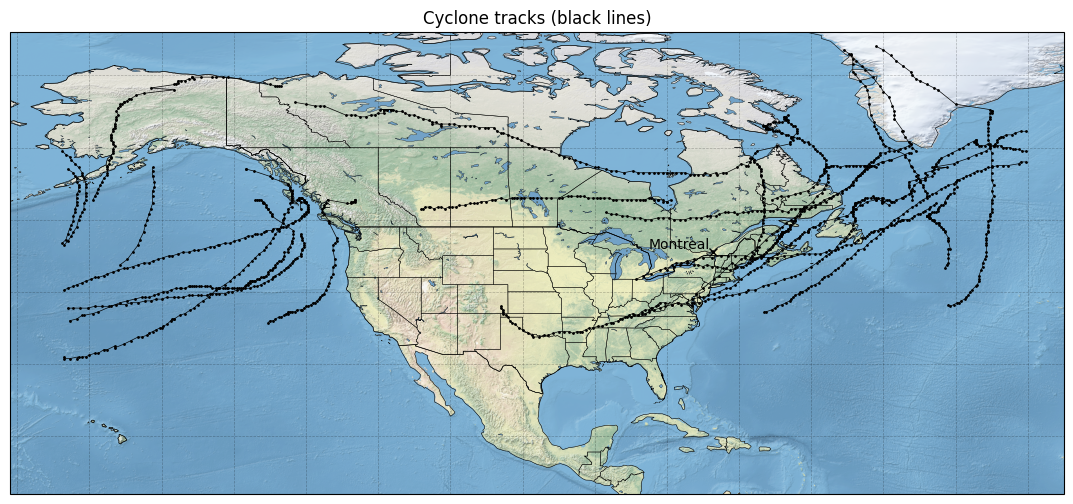

In [32]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()},
                       figsize=(14,6))

ax.set_extent([-171, -25, 76, 12], crs=ccrs.PlateCarree())

borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)

states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)

# rivers = cartopy.feature.NaturalEarthFeature(category='physical', name='rivers_lake_centerlines', scale='50m', facecolor='none')
# ax.add_feature(rivers, zorder=1, linewidth=0.3, edgecolor='blue')

lakes = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#72a2c7')
ax.add_feature(lakes, zorder=1, linewidth=0.2, edgecolor='black')

ax.coastlines(resolution='10m', linewidth=0.4, color='black')

ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))

img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

mtl_lon, mtl_lat = -73.561668, 45.508888
plt.plot(mtl_lon, mtl_lat, color='k', linewidth=20, marker='x', transform=ccrs.PlateCarree())
plt.text(mtl_lon - 0.5, mtl_lat + 0.5, 'Montreal', horizontalalignment='right', transform=ccrs.PlateCarree())

for id_storm, group in df.groupby('storm'):
    plt.plot(group.lon,group.lat, transform=ccrs.PlateCarree(), lw=0.5, color='k', marker='o',markersize=1)

plt.title('Cyclone tracks (black lines)')